<style>
p { max-width: 80em;}
</style>

## <span style="color:#ce4356">2 </span>  - Building simple inference models

**Continuous case** — We want to infer the model parameter $\theta$ (infinitely many rows in the Bayes table): 

$$
\underbrace{P(\theta\,|\,\text{Data})}_{\textstyle\color{#888888}\text{posterior}}
\;=\;
\frac{\overbrace{P(\theta)}^{\textstyle\color{#888888}\text{prior}}\;\overbrace{P(\text{Data}\,|\,\theta)}^{\textstyle\color{#888888}\text{likelihood}}}
     {\underbrace{\int P(\theta')\;P(\text{Data}\,|\,\theta')\,d\theta'}_{\textstyle\color{#888888}\text{evidence}}}
$$

$P(\theta)$ and $P(\theta\,|\,\text{Data})$ are now probability **densities**.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from bayes_tools import bayes_table, posterior_1d

# good colormaps 
from cmcrameri import cm as cmc
from cmocean import cm as cm
colors = np.vstack([cm.dense([0.25, 0.5, 0.95]),
                    cmc.acton([0.5, 0.85]),
                    cm.matter([0.1, 0.45]),
                    cm.algae([0.5,0.95])])

---
## <span style="color:#ce4356">Example 2.1 </span>  — how much chocolate is in a bun?

Life is chaos, so at least you want to know how much chocolate you are to expect from your
favourite chocolate buns. The pack promises **20 g per bun**. You buy a pack of 25 and
start weighing.

The machine puts the same amount into every bun — call it $\mu$. That is the one unknown,
and we want and we want $\color{#ce4356}{P(\mu \mid \text{Data})}$ — the
posterior density for the chocolate weight.

**Prior** — the number on the pack, believed loosely: $\mu \sim \mathcal{N}(20, 2^2)$.
The width is a guess from the head; how much it matters is something we check.

**Likelihood** — your kitchen scale is cheap and its readings wander:

$$x_i \sim \mathcal{N}(\mu,\ \sigma^2), \qquad \sigma = 2.5\ \text{g}$$

$\sigma$ comes from the scale's manual.


In [3]:
sigma = 2.5                     # scale precision [g], from its manual
mu0, sig0 = 20.0, 2.          # prior: the number on the pack

gauss = lambda x, m, s: np.exp(-0.5 * ((x - m) / s) ** 2) / (s * np.sqrt(2 * np.pi))

buns = np.array([15.2, 19.1, 22.2, 13.8, 16.6, 16.2, 18.8, 19, 14.7, 19.3, 20.6, 24, 18.2,
                 21.9, 17.7, 14.6, 20.1, 14.4, 20.2, 20, 21.5, 15.8, 19, 17.8, 21.5])

### Reminder from 1 lecture
Assuming only 1 measurmenet has been made

In [4]:
mu_coarse = np.arange(10, 30, 5.0)
prior_coarse = gauss(mu_coarse, mu0, sig0); prior_coarse /= prior_coarse.sum()
post_coarse = bayes_table([f"μ = {m:g} g" for m in mu_coarse],
                          prior=prior_coarse,
                          likelihood=gauss(buns[0], mu_coarse, sigma))

Hypotheses,prior,likelihood,prior × likelihood,posterior
μ = 10 g,3.426e-06,0.01834,6.284e-08,2.119e-06
μ = 15 g,0.04039,0.1591,0.006424,0.2167
μ = 20 g,0.9192,0.02526,0.02322,0.7832
μ = 25 g,0.04039,7.348e-05,2.968e-06,0.0001001
Totals:,1,,0.02965,1


Same calculation with $\mu$ on a continuum — prior, likelihood from that one reading, and
the posterior they make:

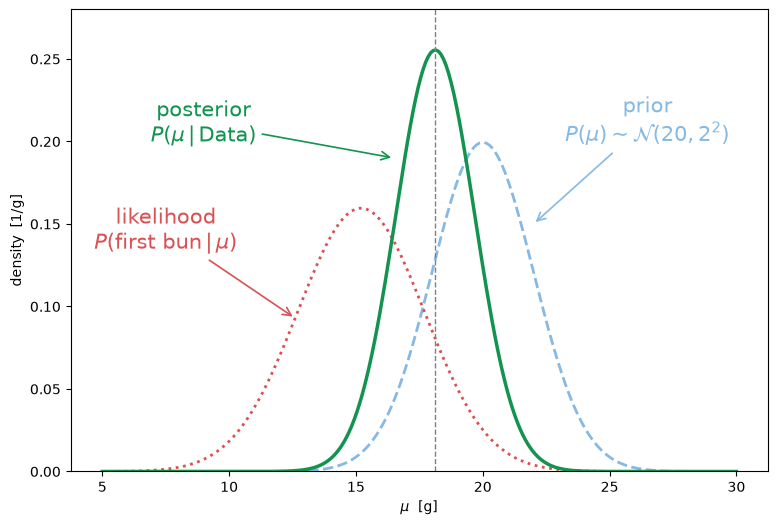

In [14]:
mu = np.linspace(5, 30, 250)
normal_prior = gauss(mu, mu0, sig0)
likelihood_one = gauss(buns[0], mu, sigma)
posterior_one, _ = posterior_1d(mu, normal_prior, likelihood_one)
mu_post = (sigma**2 * mu0 + sig0**2 * buns[0]) / (sig0**2 + sigma**2)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(mu, normal_prior, "--", lw=2, color=colors[0])
ax.plot(mu, likelihood_one, ":", lw=2, color=colors[6])
ax.plot(mu, posterior_one, lw=2.5, color=colors[-2])

A = dict(arrowstyle="->", lw=1.2)
ax.annotate(f"prior\n$P(\\mu) \\sim \\mathcal{{N}}({mu0:g}, {sig0:g}^2)$",
            xy=(22, 0.15), xytext=(26.5, 0.2),
            color=colors[0], fontsize=15, ha="center", multialignment="center",
            arrowprops=dict(A, color=colors[0]))
ax.annotate(f"likelihood\n$P(\\mathrm{{first\\ bun}}\\,|\\,\\mu)$",
            xy=(12.6, gauss(buns[0], 12.6, sigma)), xytext=(7.5, 0.135),
            color=colors[6], fontsize=15, ha="center", multialignment="center",
            arrowprops=dict(A, color=colors[6]))

ax.annotate("posterior\n$P(\\mu\\,|\\,\\mathrm{Data})$",
            xy=(16.5, 0.19), xytext=(9, 0.2),
            color=colors[-2], fontsize=15, ha="center", multialignment="center",
            arrowprops=dict(A, color=colors[-2]))

plt.axvline(mu_post, color='gray', ls='--', lw=1)
ax.set_xlabel("$\\mu$  [g]"); ax.set_ylabel("density  [1/g]")
ax.set_ylim(0, 0.28); ax.grid(False)
plt.show()

### keep weighing

The readings are independent, so the likelihood of $n$ of them is the product of the
Gaussians. Weigh 5 buns

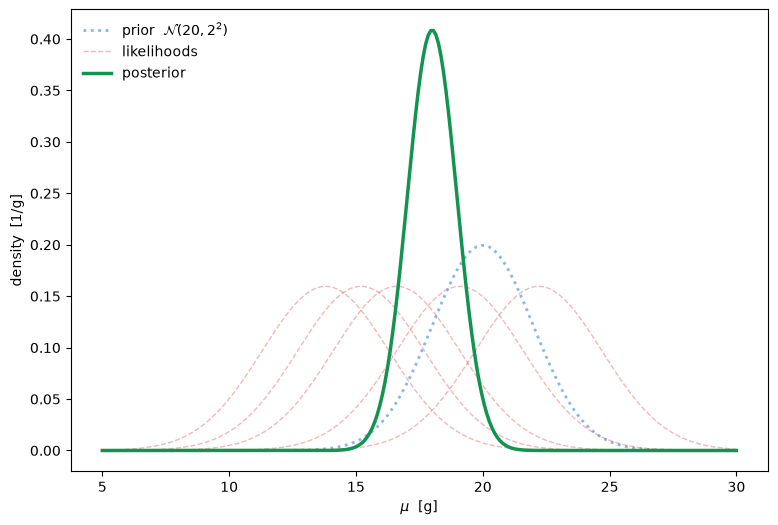

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(mu, normal_prior, ":", lw=2, color=colors[0],
        label=f"prior  $\\mathcal{{N}}({mu0:g}, {sig0:g}^2)$")

# Brute force multiply gaussians
likelihood = 1.
for j in range(5):
    ax.plot(mu, gauss(buns[j], mu, sigma), "--", lw=1, alpha=.4, color=colors[6],
            label="likelihoods" if j == 0 else None)
    likelihood = likelihood * gauss(buns[j], mu, sigma)

posterior, _ = posterior_1d(mu, normal_prior, likelihood)
ax.plot(mu, posterior, lw=2.5, color=colors[-2], label="posterior")

ax.set_xlabel("$\\mu$  [g]"); ax.set_ylabel("density  [1/g]")
ax.legend(frameon=False, loc=2)
plt.show()

### Assuming agnostic (flat) prior

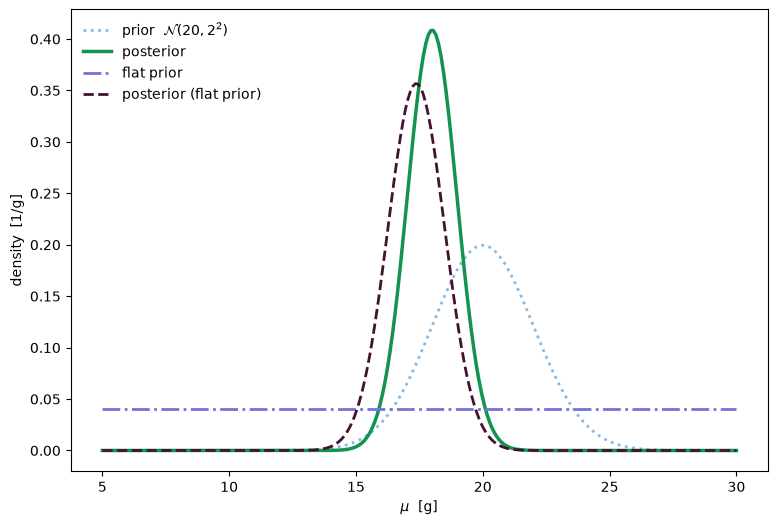

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(mu, normal_prior, ":", lw=2, color=colors[0],
        label=f"prior  $\\mathcal{{N}}({mu0:g}, {sig0:g}^2)$")

# Brute force multiply gaussians
likelihood = 1.
for j in range(5):
    likelihood = likelihood * gauss(buns[j], mu, sigma)

posterior, _ = posterior_1d(mu, normal_prior, likelihood)
ax.plot(mu, posterior, lw=2.5, color=colors[-2], label="posterior")

flat_prior = np.ones_like(mu) / (mu[-1] - mu[0])       # = 1/25 per gram
posterior_flat, _ = posterior_1d(mu, flat_prior, likelihood)
ax.plot(mu, flat_prior, ls="-.", lw=2, color=colors[1], label="flat prior")
ax.plot(mu, posterior_flat, lw=2, ls='--', color=colors[2], label="posterior (flat prior)")

ax.set_xlabel("$\\mu$  [g]"); ax.set_ylabel("density  [1/g]")
ax.legend(frameon=False, loc=2)
plt.show()

### Weigh 25 buns 

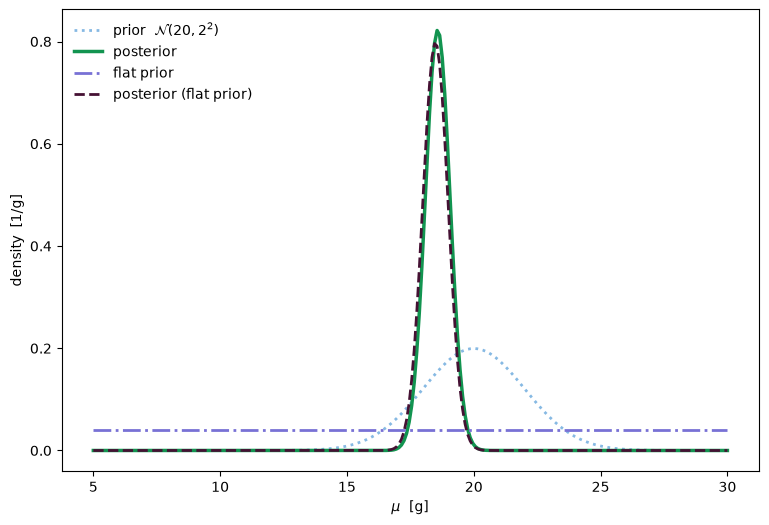

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(mu, normal_prior, ":", lw=2, color=colors[0],
        label=f"prior  $\\mathcal{{N}}({mu0:g}, {sig0:g}^2)$")

# Brute force multiply gaussians
likelihood = 1.
for j in range(25):
    likelihood = likelihood * gauss(buns[j], mu, sigma)

posterior, _ = posterior_1d(mu, normal_prior, likelihood)
ax.plot(mu, posterior, lw=2.5, color=colors[-2], label="posterior")

flat_prior = np.ones_like(mu) / (mu[-1] - mu[0])       # = 1/25 per gram
posterior_flat, _ = posterior_1d(mu, flat_prior, likelihood)
ax.plot(mu, flat_prior, "-.", lw=2, color=colors[1], label="flat prior")
ax.plot(mu, posterior_flat, lw=2.,ls='--', color=colors[2], label="posterior (flat prior)")

ax.set_xlabel("$\\mu$  [g]"); ax.set_ylabel("density  [1/g]")
ax.legend(frameon=False, loc=2)
plt.show()

### What to take from this

- The posterior is prior × likelihood, renormalised.

- The independent measurements (different buns) provide likelihoods that can be multiplied.

- The prior dependence does not go away, but it gets outweighed by the data. In the limit
  of infinite data the posteriors should converge (with a caveat we explore next).

- The posterior distribution *is* the answer to "how much chocolate should I expect".
  Every summary you might quote — a best value, mean, credible interval, any fitted universal relation — is read off this one curve.

---

## <span style="color:#ce4356">Example 2.2 </span>  — the binary neutron star merger rate

Before GW170817 — the first BNS detection — what did we expect? Abadie et al. (2010)
extrapolated from the Galactic binary pulsars and predicted, for the Advanced
LIGO–Virgo network at design sensitivity:

| prediction | $R$ = detections / year |
|:---|---:|
| low | 0.4 |
| realistic | 40 |
| high | 400 |
| maximum | 1000 |

Three orders of magnitude of honest uncertainty. Then GW170817 arrived: **one** BNS
detection in O1 + O2. The exposure time $T$ is the live time with both detectors observing — 48 days in O1
and 117 in O2, so $T \approx 165\ \text{d} = 0.45$ yr.

**How does this single data point change our estimate?**

In [9]:
N_obs = 1                      # GW170817, the only BNS in O1+O2
T_obs = (48 + 117) / 365.25     # live time [yr]

### <span style="color:#ce4356">a) </span> The inference

The model parameter we want to infer is the rate $R$.

**The likelihood** is Poisson (see derivation in the notes) — independent events at a constant rate, so the number seen in time $T$ has mean $RT$:

$$P(N \mid R) \;=\; \frac{(RT)^N}{N!}\,e^{-RT}$$

In [10]:
def poisson_likelihood(R, N=N_obs, T=T_obs):
    '''P(N | R) for a Poisson process, evaluated in log space '''
    log_factorial = np.log(np.arange(1, N + 1)).sum()
    return np.exp(N * np.log(R * T) - R * T - log_factorial)

R = np.linspace(1e-3, 200, 4000)      # fine enough to resolve a posterior of width ~2

mu_R, sigma_R = 40.0, 20.0
prior_gauss = np.exp(-0.5 * ((R - mu_R) / sigma_R) ** 2)        # truncated at R > 0
prior_gauss /= np.trapezoid(prior_gauss, R)

likelihood = poisson_likelihood(R)
posterior_gauss, evidence_gauss = posterior_1d(R, prior_gauss, likelihood)

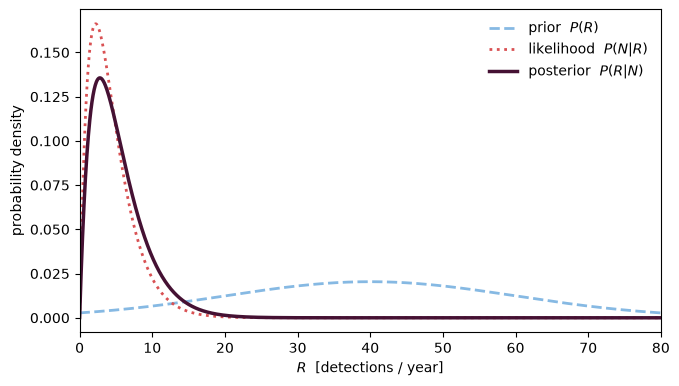

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(R, prior_gauss, "--", lw=2, color=colors[0], label="prior  $P(R)$")
ax.plot(R, likelihood / np.trapezoid(likelihood, R), ":", lw=2, color=colors[6],
        label="likelihood  $P(N|R)$")
ax.plot(R, posterior_gauss, lw=2.5, color=colors[2], label="posterior  $P(R|N)$")
ax.set_xlim(0, 80)
ax.set_xlabel("$R$  [detections / year]"); ax.set_ylabel("probability density")
ax.grid(False); ax.legend(frameon=False)
plt.show()

### <span style="color:#ce4356">b) </span> What if the prior is too restrictive?

Suppose we had been more confident and allowed only $10 < R < 100$ per year — a Beta prior
on that interval, and zero outside it.

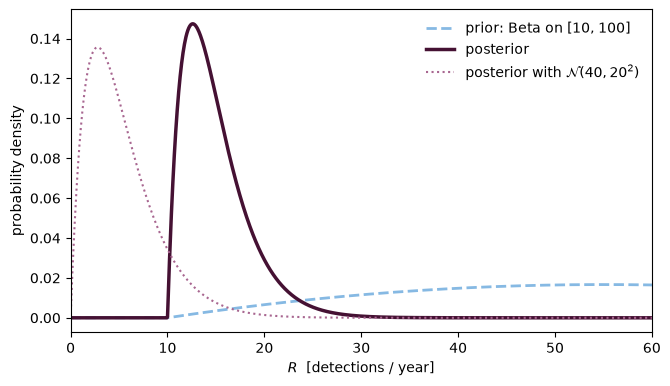

In [12]:
def beta_prior(lo, hi, a=2, b=2):
    '''Beta(a, b) rescaled onto [lo, hi]; identically zero outside.'''
    
    u = (R - lo) / (hi - lo)
    p = np.where((u > 0) & (u < 1), u ** (a - 1) * (1 - u) ** (b - 1), 0.0)
    return p / np.trapezoid(p, R)

prior_beta = beta_prior(10, 100)
posterior_beta, evidence_beta = posterior_1d(R, prior_beta, likelihood)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(R, prior_beta, "--", lw=2, color=colors[0], label="prior: Beta on [10, 100]")
ax.plot(R, posterior_beta, lw=2.5, color=colors[2], label="posterior")
ax.plot(R, posterior_gauss, ":", lw=1.5, color=colors[3],
        label="posterior with $\\mathcal{N}(40, 20^2)$")
ax.set_xlim(0, 60); ax.set_xlabel("$R$  [detections / year]")
ax.set_ylabel("probability density"); ax.grid(False); ax.legend(frameon=False)
plt.show()

The posterior is jammed against the lower edge of the prior. No amount of data recovers
a value you excluded at the start, so posteriors converge only if the truth was allowed in
the first place.

### <span style="color:#ce4356">c) </span> What if the likelihood is not informative?

Now rewind to the first day of O1, with no detection at all: $N = 0$, $T = 1/365$ yr.

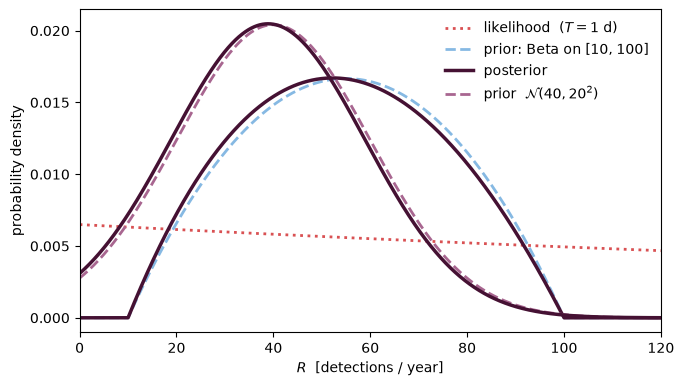

In [13]:
N_day, T_day = 0, 1 / 365.25                        # first day of O1, nothing seen
likelihood_day = poisson_likelihood(R, N_day, T_day)

posterior_gauss_day, _ = posterior_1d(R, prior_gauss, likelihood_day)
posterior_beta_day, _ = posterior_1d(R, prior_beta, likelihood_day)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(R, likelihood_day / np.trapezoid(likelihood_day, R), ":", lw=2, color=colors[6],
        label=f"likelihood  ($T={T_day*365.25:.0f}$ d)")
ax.plot(R, prior_beta, "--", lw=2, color=colors[0], label="prior: Beta on [10, 100]")
ax.plot(R, posterior_beta_day, lw=2.5, color=colors[2], label="posterior")
ax.plot(R, prior_gauss, "--", lw=2, color=colors[3], label="prior  $\\mathcal{N}(40, 20^2)$")
ax.plot(R, posterior_gauss_day, lw=2.5, color=colors[2])

ax.set_xlim(0, 120); ax.set_xlabel("$R$  [detections / year]")
ax.set_ylabel("probability density"); ax.grid(False); ax.legend(frameon=False)
plt.show()

Each posterior lies on top of its own prior. The likelihood carries no information about
$R$ — one day of observing and seeing nothing simply hands the prior back to you.

### In both cases the prior is driving the posterior

In practice:

- change the prior, or tweak its parameters, and see whether the answer moves — and by how much
- check whether the posterior sits in the *tail* of the prior, or against its edge
- ask whether there was a physical reason to cut the prior there, or only convenience

There are more formal quantifications of these effects — e.g. *prior predictive checks* and
*prior–data conflict* tests — but in my experience they are rarely used in astro
(though perhaps they should be), and for now they are outside the scope of an introductory
course.